<a href="https://colab.research.google.com/github/sinchanarhegde/New-York-City-Yellow-Taxi-Data-Analysis/blob/main/New_York_City_Yellow_Taxi_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this project, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description


**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|



**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.


---

## **1.** Data Preparation

In [ ]:
# Import warnings

import warnings

In [ ]:
# Import the necessary libraries used for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.0.2
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset

In [ ]:
# Accessing the file from google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
# accessing the file for sampling
os.chdir('/content/drive/MyDrive/Colab Notebooks/trip_parquet')
file_list = [f for f in os.listdir() if f.endswith('.parquet')]
file_list.sort()

# initialising an empty DataFrame
final_df = pd.DataFrame()

# Iterate over .parquet file in folder
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        print(f"Reading: {file_name}")
        month_df = pd.read_parquet(file_path)

        # pickup column is datetime
        month_df['tpep_pickup_datetime'] = pd.to_datetime(month_df['tpep_pickup_datetime'])
        month_sampled_data = pd.DataFrame()

        # Get unique dates in this month file
        unique_dates = month_df['tpep_pickup_datetime'].dt.date.unique()

        # Loop through dates and then loop through every hour of each date
        for current_date in unique_dates:
            # Filter data for the specific day
            day_df = month_df[month_df['tpep_pickup_datetime'].dt.date == current_date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                # Filter data for the specific hour
                hourly_data = day_df[day_df['tpep_pickup_datetime'].dt.hour == hour]

                # Sample 5% of the hourly data randomly
                if not hourly_data.empty:
                    # n=1 ensures we get at least one record if the hour is very quiet otherwise use frac=0.05
                    sampled_hour = hourly_data.sample(frac=0.05, random_state=42)
                    # add data of this hour to the dataframe
                    month_sampled_data = pd.concat([month_sampled_data, sampled_hour])

        # Concatenate the sampled data of all the dates to a single dataframe
        final_df = pd.concat([final_df, month_sampled_data], ignore_index=True)
        print(f"Completed sampling for {file_name}. Total rows now: {len(final_df)}")

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

Reading: 2023-1.parquet
Completed sampling for 2023-1.parquet. Total rows now: 152087
Reading: 2023-10.parquet
Completed sampling for 2023-10.parquet. Total rows now: 326342
Reading: 2023-11.parquet
Completed sampling for 2023-11.parquet. Total rows now: 491475
Reading: 2023-12.parquet
Completed sampling for 2023-12.parquet. Total rows now: 658184
Reading: 2023-2.parquet
Completed sampling for 2023-2.parquet. Total rows now: 826880
Reading: 2023-3.parquet
Completed sampling for 2023-3.parquet. Total rows now: 990666
Reading: 2023-4.parquet
Completed sampling for 2023-4.parquet. Total rows now: 1130307
Reading: 2023-5.parquet
Completed sampling for 2023-5.parquet. Total rows now: 1274765
Reading: 2023-6.parquet
Completed sampling for 2023-6.parquet. Total rows now: 1437675
Reading: 2023-7.parquet
Completed sampling for 2023-7.parquet. Total rows now: 1611743
Reading: 2023-8.parquet
Completed sampling for 2023-8.parquet. Total rows now: 1755525
Reading: 2023-9.parquet
Completed sampling 


Ideally, keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in the form of .parquet file in drive
output_file_path = '/content/drive/MyDrive/Colab Notebooks/trip_parquet/sampled_taxi_data_2023.parquet'
target_size = 275000
if len(final_df) > target_size:
    print(f"Current size ({len(final_df)}) is above target. Sampling down to {target_size}...")
    final_df_subset = final_df.sample(n=target_size, random_state=42).reset_index(drop=True)
else:
    print(f"Current size ({len(final_df)}) is within target range.")
    final_df_subset = final_df
final_df_subset.to_parquet(output_file_path, index=False)
print(f"Success! Sampled data saved to: {output_file_path}")

Current size (1896400) is above target. Sampling down to 275000...
Success! Sampled data saved to: /content/drive/MyDrive/Colab Notebooks/trip_parquet/sampled_taxi_data_2023.parquet


## **2.** Data Cleaning

Now we can load the new data directly.

In [ ]:
# Load the new data file
df = pd.read_parquet('sampled_taxi_data_2023.parquet')


In [ ]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,N,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,NaN,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,N,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.0,NaN
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,N,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,NaN,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,N,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,NaN,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,N,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,NaN,0.00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275000 entries, 0 to 274999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               275000 non-null  int64         
 1   tpep_pickup_datetime   275000 non-null  datetime64[us]
 2   tpep_dropoff_datetime  275000 non-null  datetime64[us]
 3   passenger_count        265634 non-null  float64       
 4   trip_distance          275000 non-null  float64       
 5   RatecodeID             265634 non-null  float64       
 6   store_and_fwd_flag     265634 non-null  object        
 7   PULocationID           275000 non-null  int64         
 8   DOLocationID           275000 non-null  int64         
 9   payment_type           275000 non-null  int64         
 10  fare_amount            275000 non-null  float64       
 11  extra                  275000 non-null  float64       
 12  mta_tax                275000 non-null  floa

#### **2.1** Fixing Columns

In [ ]:
# Fixing the index and dropped the 'store_and_fwd_flag' column which is not needed for analysis
df = df.reset_index(drop=True)
df = df.drop(columns=['store_and_fwd_flag'], errors='ignore')
df


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,NaN,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.0,NaN
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,NaN,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,NaN,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,NaN,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,NaN,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,NaN,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,NaN,0.00



There are two airport fee columns. This is possibly an error in naming columns.

In [ ]:
# Combining the two airport fee columns
if 'Airport_fee' in df.columns and 'airport_fee' in df.columns:
    df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

df = df.drop(columns=['Airport_fee'], errors='ignore')
df


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
# checking whether values of fare amount are negative
df[df['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


In [ ]:
# Analysing RatecodeID for the negative fare amounts
negative_fares = df[df['fare_amount'] < 0]
ratecode_analysis = negative_fares['RatecodeID'].value_counts().sort_index()
print(ratecode_analysis)

Series([], Name: count, dtype: int64)


In [ ]:
# Finding which columns have negative values
numeric_df = df.select_dtypes(include=['number'])
cols_with_negatives = (numeric_df < 0).any()
negative_columns_list = cols_with_negatives[cols_with_negatives == True].index.tolist()

print("Columns containing negative values:")
print(negative_columns_list)


Columns containing negative values:
['mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


In [ ]:
# fixing these negative values
neg_cols = ['mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
for col in neg_cols:
    df[col] = df[col].abs()

### **2.2** Handling Missing Values

In [ ]:
# Finding the proportion of missing values in each column
df.isnull().mean()

,0
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
passenger_count,0.034058
trip_distance,0.000000
RatecodeID,0.034058
PULocationID,0.000000
DOLocationID,0.000000
payment_type,0.000000
fare_amount,0.000000


In [ ]:
# Displayed the rows with null values
df[df.isnull().any(axis=1)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
39,1,2023-12-12 19:05:58,2023-12-12 19:10:51,NaN,0.80,NaN,137,107,0,6.50,2.5,0.5,1.95,0.00,1.0,14.95,NaN,NaN
52,2,2023-12-10 04:33:21,2023-12-10 04:37:46,NaN,1.21,NaN,137,229,0,1.00,0.0,0.5,0.00,0.00,1.0,5.00,NaN,NaN
74,2,2023-02-04 00:07:05,2023-02-04 00:19:55,NaN,1.98,NaN,231,232,0,12.91,0.0,0.5,2.53,0.00,1.0,19.44,NaN,NaN
89,2,2023-01-01 03:28:00,2023-01-01 03:38:00,NaN,3.70,NaN,79,140,0,18.95,0.0,0.5,4.59,0.00,1.0,27.54,NaN,NaN
95,2,2023-07-12 08:55:00,2023-07-12 09:07:00,NaN,2.49,NaN,262,162,0,17.84,0.0,0.5,3.28,0.00,1.0,25.12,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274795,2,2023-05-04 17:11:48,2023-05-04 18:27:07,NaN,16.94,NaN,186,1,0,76.96,0.0,0.0,7.42,14.75,1.0,100.13,NaN,NaN
274839,2,2023-06-29 10:26:57,2023-06-29 10:48:21,NaN,6.01,NaN,244,143,0,26.01,0.0,0.5,0.00,0.00,1.0,30.01,NaN,NaN
274841,2,2023-08-23 09:20:00,2023-08-23 09:33:00,NaN,3.58,NaN,263,233,0,20.11,0.0,0.5,4.82,0.00,1.0,28.93,NaN,NaN
274901,2,2023-05-06 23:10:50,2023-05-06 23:33:12,NaN,3.99,NaN,249,236,0,24.77,0.0,0.5,2.88,0.00,1.0,31.65,NaN,NaN


In [ ]:
# Imputed NaN values in 'passenger_count' with mode value
passenger_mode = df['passenger_count'].mode()[0]
df['passenger_count'] = df['passenger_count'].fillna(passenger_mode)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
# Fixed missing values in 'RatecodeID' with mode value
ratecode_mode = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(ratecode_mode)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
# handling null values in congestion_surcharge
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
# Handling remaining missing values in dataset
df['airport_fee'] = df['airport_fee'].fillna(0)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


### **2.3** Handling Outliers

In [ ]:
# Described the data and checkig if there are any potential outliers present
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,275000.000000,275000,275000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000,275000.000000
mean,1.733276,2023-07-03 00:23:32.238156,2023-07-03 00:40:57.055323,1.356629,3.751835,1.619545,165.146680,164.084113,1.164353,19.824415,1.585467,0.495266,3.549025,0.590183,0.998976,28.878929,2.228164,0.138009
min,1.000000,2023-01-01 00:04:55,2023-01-01 00:10:20,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 20:33:10.250000,2023-04-02 20:53:43.500000,1.000000,1.040000,1.000000,132.000000,114.000000,1.000000,9.300000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-27 17:32:36.500000,2023-06-27 17:56:23.500000,1.000000,1.790000,1.000000,162.000000,162.000000,1.000000,13.500000,1.000000,0.500000,2.850000,0.000000,1.000000,21.000000,2.500000,0.000000
75%,2.000000,2023-10-06 21:40:26.250000,2023-10-06 21:55:39.500000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.900000,2.500000,0.500000,4.420000,0.000000,1.000000,30.800000,2.500000,0.000000
max,6.000000,2023-12-31 23:43:25,2024-01-01 00:15:03,8.000000,22910.920000,99.000000,265.000000,265.000000,4.000000,999.000000,20.800000,0.800000,200.000000,87.500000,1.000000,1000.000000,2.500000,1.750000
std,0.447885,NaN,NaN,0.879434,72.176235,7.308563,64.137043,69.816233,0.507066,18.392627,1.829127,0.048542,4.134597,2.176775,0.029429,22.933098,0.778266,0.457631


In [ ]:
# Checking for potential out of place values in various columns
print((df['fare_amount'] == 0).sum())
print((df['trip_distance'] == 0).sum())

100
5369


In [ ]:
# Calculating the duration in minutes
duration = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

print(f"Trips with negative duration: {(duration < 0).sum()}")
print(f"Trips longer than 24 hours: {(duration > 1440).sum()}")
print(f"Trips with 0 minute duration: {(duration == 0).sum()}")


Trips with negative duration: 19
Trips longer than 24 hours: 1
Trips with 0 minute duration: 109


In [ ]:
# Checking for 0 or > 6 passengers
print(f"Trips with 0 passengers: {(df['passenger_count'] == 0).sum()}")
print(f"Trips with > 6 passengers: {(df['passenger_count'] > 6).sum()}")

Trips with 0 passengers: 4274
Trips with > 6 passengers: 1


In [ ]:
# Defined Ratecodes are 1-6. 99 is usually 'Unknown'
print("Unique RatecodeIDs:", df['RatecodeID'].unique())

# Defined Payment types are 1-6
print("Unique Payment Types:", df['payment_type'].unique())

Unique RatecodeIDs: [ 1.  2.  3.  5. 99.  4.  6.]
Unique Payment Types: [1 2 3 0 4]


In [ ]:
#Entries where trip_distance is nearly 0 and fare_amount is more than 300
df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
24018,2,2023-11-26 16:04:06,2023-11-26 16:04:12,1.0,0.0,5.0,265,265,1,305.14,0.0,0.0,61.23,0.00,1.0,367.37,0.0,0.0
75869,2,2023-06-21 12:05:21,2023-06-21 12:05:42,1.0,0.0,5.0,265,265,2,500.00,0.0,0.0,0.00,0.00,1.0,501.00,0.0,0.0
94360,1,2023-01-11 12:38:54,2023-01-11 12:38:54,0.0,0.0,99.0,264,264,1,450.00,0.0,0.0,0.00,0.00,0.0,450.00,0.0,0.0
141633,2,2023-04-05 21:16:43,2023-04-05 21:25:57,1.0,0.0,5.0,265,265,2,600.00,0.0,0.0,0.00,0.00,1.0,601.00,0.0,0.0
148673,1,2023-03-31 16:56:04,2023-03-31 16:57:02,1.0,0.0,5.0,181,181,4,500.00,0.0,0.0,0.00,0.00,1.0,501.00,0.0,0.0
250378,1,2023-01-09 16:17:32,2023-01-09 16:20:41,1.0,0.0,5.0,141,141,3,999.00,0.0,0.0,0.00,0.00,1.0,1000.00,0.0,0.0
262731,2,2023-07-27 19:30:15,2023-07-27 19:30:50,1.0,0.0,5.0,265,265,4,500.00,0.0,0.0,0.00,6.55,1.0,507.55,0.0,0.0
272900,2,2023-08-01 22:06:03,2023-08-01 22:06:41,2.0,0.0,5.0,39,39,3,500.00,0.0,0.0,0.00,0.00,1.0,501.00,0.0,0.0


In [ ]:
#Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different
(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']).sum()

,0
0,False
1,False
2,False
3,False
4,False
...,...
274995,False
274996,False
274997,False
274998,False


In [ ]:
# Entries where trip_distance is more than 250 miles.
df['trip_distance'] > 250

,trip_distance
0,False
1,False
2,False
3,False
4,False
...,...
274995,False
274996,False
274997,False
274998,False


In [ ]:
# Entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
df['payment_type'] == 0

,payment_type
0,False
1,False
2,False
3,False
4,False
...,...
274995,False
274996,False
274997,False
274998,False


In [ ]:
# removed entries where passenger_count > 6
df = df[df['passenger_count'] <= 6]
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274995,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274996,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274997,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274998,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
# Continued with outlier handling
anomalous_trips = df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)]
df = df.drop(anomalous_trips.index).reset_index(drop=True)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274986,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274987,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274988,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274989,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
zero_dist_fare_diff_zone = df[(df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID'])].index
df = df.drop(zero_dist_fare_diff_zone).reset_index(drop=True)
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274975,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274976,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274977,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274978,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


In [ ]:
# removed entries where passenger_count < 0
df = df[df['passenger_count'] > 0]
df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,1.0,0.5,5.50,0.00,1.0,27.50,2.5,0.00
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,0.0,0.5,0.00,0.00,1.0,14.00,2.5,0.00
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,0.0,0.5,10.00,6.55,1.0,89.30,0.0,1.25
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,0.0,0.5,5.46,0.00,1.0,32.76,2.5,0.00
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,2.5,0.5,3.58,0.00,1.0,21.48,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274975,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,2.5,0.5,2.00,0.00,1.0,29.30,2.5,0.00
274976,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,0.0,0.5,2.80,0.00,1.0,16.80,2.5,0.00
274977,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,2.5,0.5,1.00,0.00,1.0,21.00,2.5,0.00
274978,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,0.0,0.5,0.00,0.00,1.0,15.40,2.5,0.00


## **3.** Exploratory Data Analysis


In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

### **3.1** General EDA: Finding Patterns and Trends


In [ ]:
# Catergorical columns
categorical_vars = [
    'VendorID',
    'RatecodeID',
    'PULocationID',
    'DOLocationID',
    'payment_type'
]

In [ ]:
# Numerical columns
numerical_vars = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'airport_fee'
]

In [ ]:
# DateTime columns
datetime_vars = [
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime'
]

### Temporal Analysis

/tmp/ipython-input-2759589167.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour


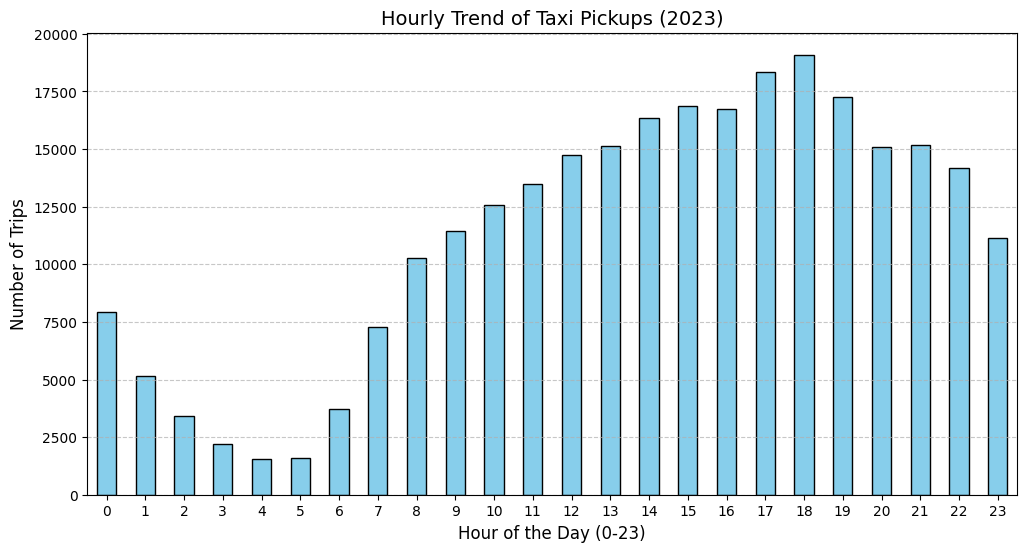

In [ ]:
# Analysing the hourly trends in taxi pickups
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_trends = df.groupby('pickup_hour').size()

plt.figure(figsize=(12, 6))
hourly_trends.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Hourly Trend of Taxi Pickups (2023)', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/tmp/ipython-input-1673679122.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_name'] = df['tpep_pickup_datetime'].dt.day_name()
/tmp/ipython-input-1673679122.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_number'] = df['tpep_pickup_datetime'].dt.dayofweek


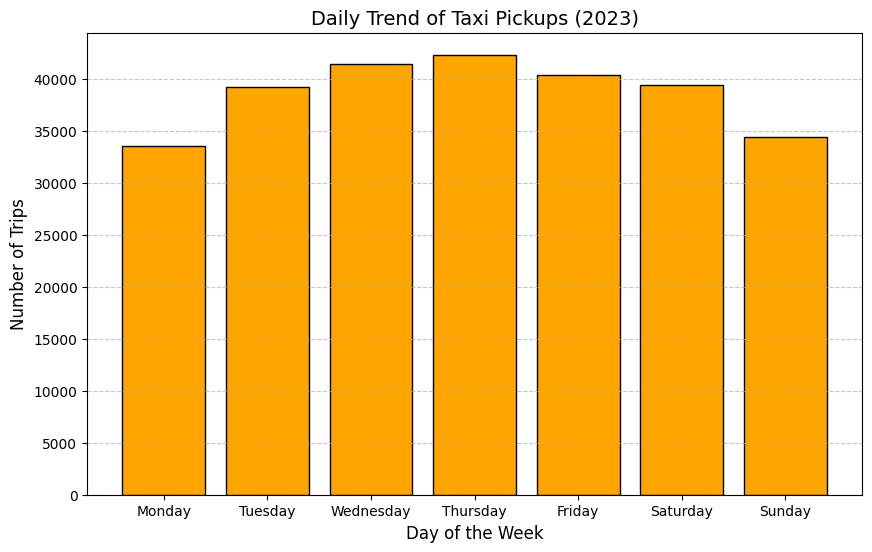

In [ ]:
# Analysing the daily trends in taxi pickups (days of the week)
df['day_name'] = df['tpep_pickup_datetime'].dt.day_name()
df['day_number'] = df['tpep_pickup_datetime'].dt.dayofweek

daily_trends = df.groupby(['day_number', 'day_name']).size().reset_index(name='trip_count')
daily_trends = daily_trends.sort_values('day_number')

plt.figure(figsize=(10, 6))
plt.bar(daily_trends['day_name'], daily_trends['trip_count'], color='orange', edgecolor='black')
plt.title('Daily Trend of Taxi Pickups (2023)', fontsize=14)
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()


/tmp/ipython-input-3726654133.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_name'] = df['tpep_pickup_datetime'].dt.month_name()
/tmp/ipython-input-3726654133.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
/tmp/ipython-input-3726654133.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current beha

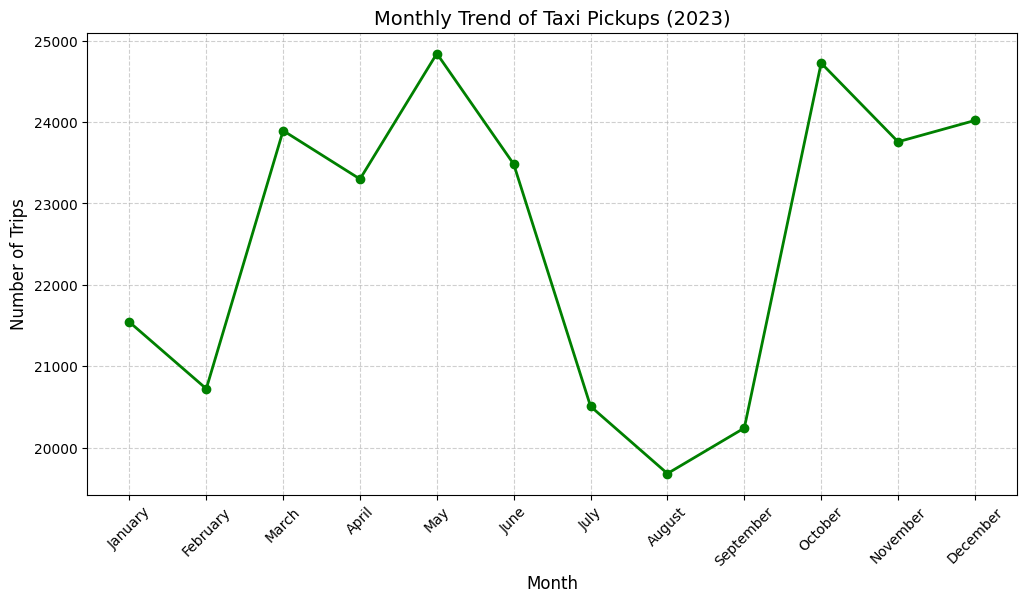

In [ ]:
# Analysing the monthly trends in pickups
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December']

df['month_name'] = df['tpep_pickup_datetime'].dt.month_name()
df['month_name'] = pd.Categorical(df['month_name'], categories=month_order, ordered=True)
monthly_trends = df.groupby('month_name').size()

plt.figure(figsize=(12, 6))
monthly_trends.plot(kind='line', marker='o', color='green', linewidth=2)
plt.title('Monthly Trend of Taxi Pickups (2023)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(range(len(month_order)), month_order, rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


### Financial Analysis

In [ ]:
# Analysing the 'fare_amount', 'tip_amount', 'total_amount', 'trip_distance' parameters
params = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
for p in params:
    neg_count = (df[p] < 0).sum()
    zero_count = (df[p] == 0).sum()
    print(f"{p}: Negatives = {neg_count}, Zeros = {zero_count}")


fare_amount: Negatives = 0, Zeros = 84
tip_amount: Negatives = 0, Zeros = 62335
total_amount: Negatives = 0, Zeros = 40
trip_distance: Negatives = 0, Zeros = 5235


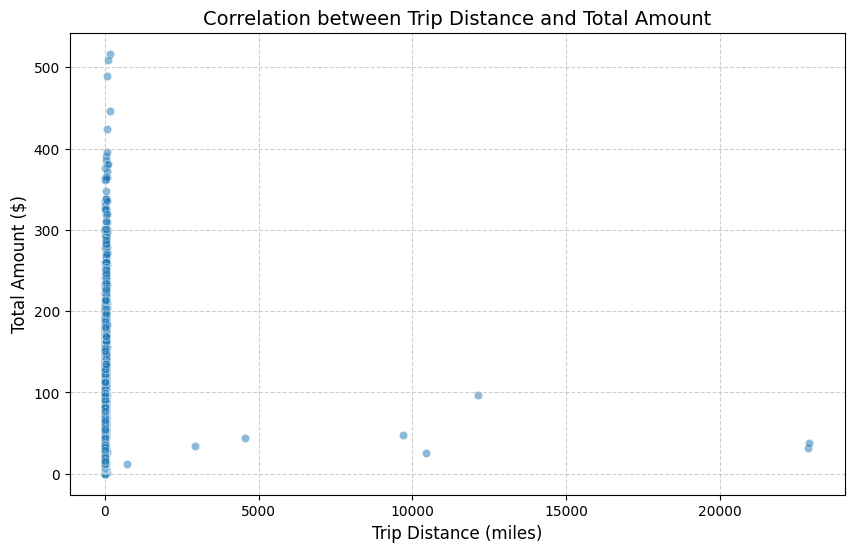

In [ ]:
# Analysing the 'total_amount', 'trip_distance' parameter
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='trip_distance', y='total_amount', alpha=0.5)

plt.title('Correlation between Trip Distance and Total Amount', fontsize=14)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Total Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# Finding the correlation between above parameters
df[params].corr()

,fare_amount,tip_amount,total_amount,trip_distance
fare_amount,1.000000,0.583968,0.978621,0.060269
tip_amount,0.583968,1.000000,0.711357,0.037160
total_amount,0.978621,0.711357,1.000000,0.059712
trip_distance,0.060269,0.037160,0.059712,1.000000


In [ ]:
df1 = df.copy()

In [ ]:
# Created a dataframe with non zero entries for the selected parameters.
analysis_df = df[
    (df['trip_distance'] > 0) &
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0)
].copy()


/tmp/ipython-input-1794314135.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_revenue = df.groupby('month_name')['total_amount'].sum()


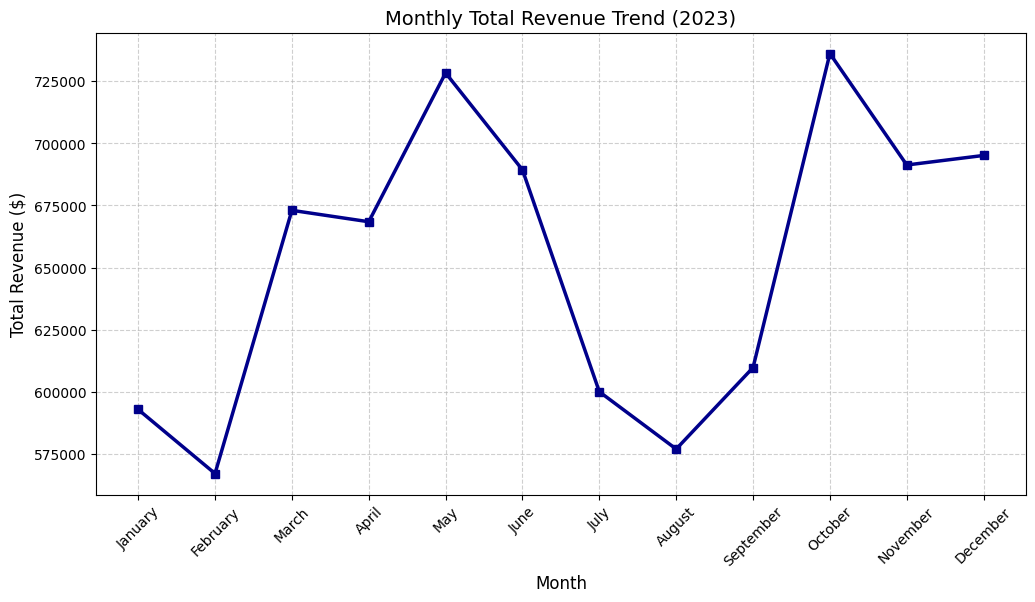

In [ ]:
# Grouping the data by month and analysing monthly revenue
monthly_revenue = df.groupby('month_name')['total_amount'].sum()

plt.figure(figsize=(12, 6))
monthly_revenue.plot(kind='line', marker='s', color='darkblue', linewidth=2.5)

plt.title('Monthly Total Revenue Trend (2023)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(len(month_order)), month_order, rotation=45)

plt.show()


/tmp/ipython-input-2574090904.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quarter'] = df['tpep_pickup_datetime'].dt.quarter


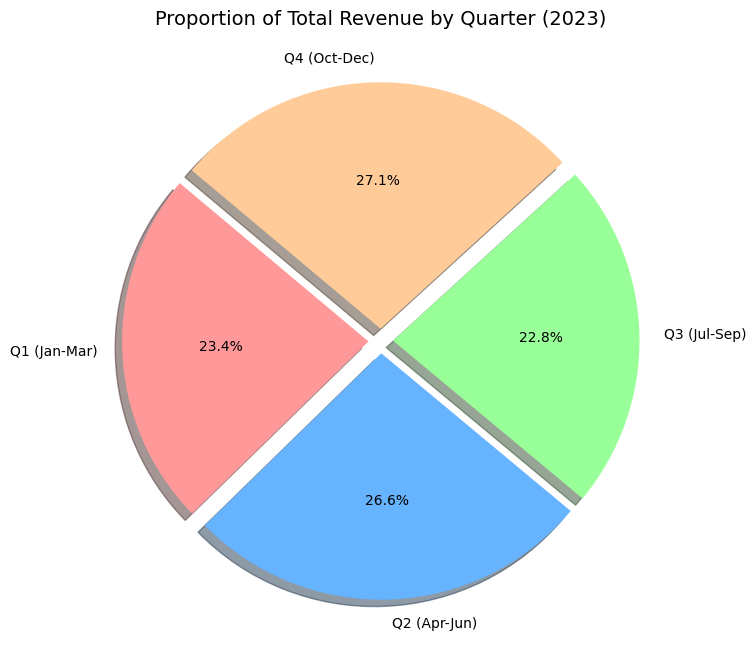

In [ ]:
# Calculated proportion of each quarter
df['quarter'] = df['tpep_pickup_datetime'].dt.quarter
quarterly_revenue = df.groupby('quarter')['total_amount'].sum()

labels = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99']

plt.figure(figsize=(8, 8))
plt.pie(quarterly_revenue, labels=labels, autopct='%1.1f%%',
        startangle=140, colors=colors, explode=(0.05, 0.05, 0.05, 0.05), shadow=True)

plt.title('Proportion of Total Revenue by Quarter (2023)', fontsize=14)
plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

Correlation between Trip Distance and Fare Amount: 0.9425


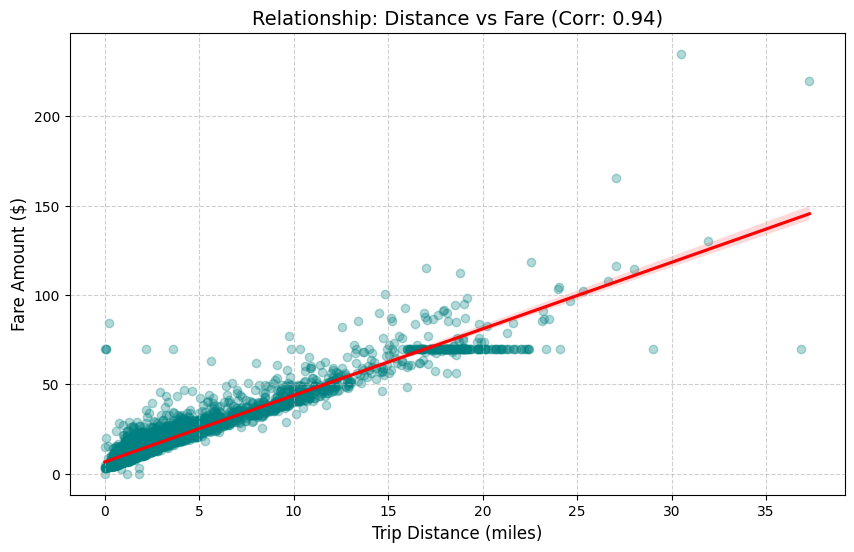

In [ ]:
# Analysed how trip fare ampount is affected by trip distance
plot_df = df[(df['trip_distance'] > 0) & (df['trip_distance'] < 50)].copy()

correlation_value = plot_df['trip_distance'].corr(plot_df['fare_amount'])
print(f"Correlation between Trip Distance and Fare Amount: {correlation_value:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(data=plot_df.sample(n=min(5000, len(plot_df)), random_state=42),
            x='trip_distance', y='fare_amount',
            scatter_kws={'alpha':0.3, 'color':'teal'},
            line_kws={'color':'red'})

plt.title(f'Relationship: Distance vs Fare (Corr: {correlation_value:.2f})', fontsize=14)
plt.xlabel('Trip Distance (miles)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


/tmp/ipython-input-2480913892.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60


Correlation between Trip Duration and Fare Amount: 0.8149


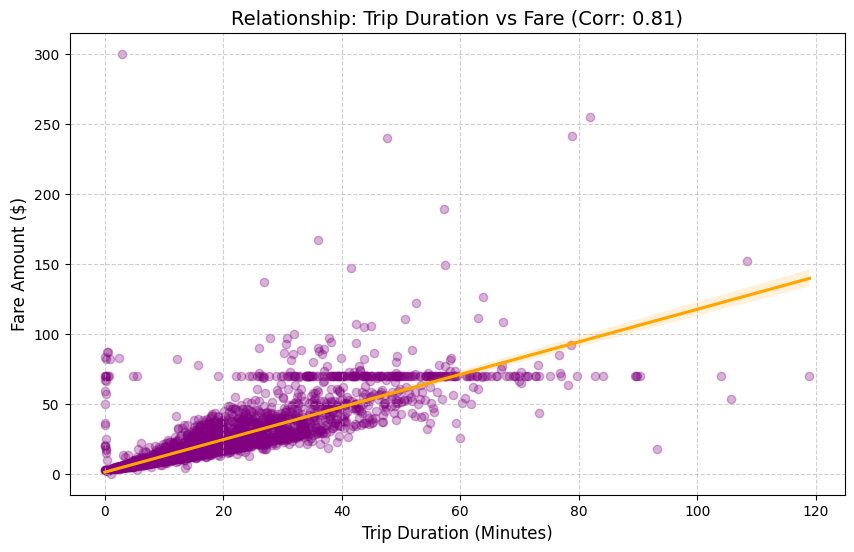

In [ ]:
# Analysing the relationship between fare and trip duration
df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

duration_df = df[(df['trip_duration'] > 0) &
                       (df['trip_duration'] < 120) &
                       (df['fare_amount'] > 0)].copy()

duration_corr = duration_df['trip_duration'].corr(duration_df['fare_amount'])
print(f"Correlation between Trip Duration and Fare Amount: {duration_corr:.4f}")

plt.figure(figsize=(10, 6))

sns.regplot(data=duration_df.sample(n=min(5000, len(duration_df)), random_state=42),
            x='trip_duration', y='fare_amount',
            scatter_kws={'alpha':0.3, 'color':'purple'},
            line_kws={'color':'orange'})

plt.title(f'Relationship: Trip Duration vs Fare (Corr: {duration_corr:.2f})', fontsize=14)
plt.xlabel('Trip Duration (Minutes)', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


/tmp/ipython-input-414469059.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample_df, x='passenger_count', y='fare_amount', palette='Set3')


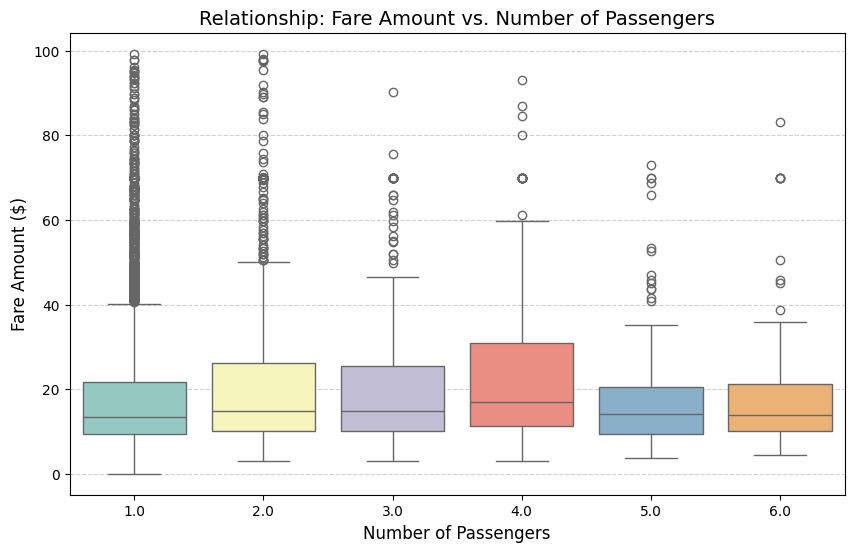

In [ ]:
# Analising the relationship between fare and number of passengers
sample_df = df[df['fare_amount'] < 100].sample(n=min(10000, len(df)))

plt.figure(figsize=(10, 6))
sns.boxplot(data=sample_df, x='passenger_count', y='fare_amount', palette='Set3')
plt.title('Relationship: Fare Amount vs. Number of Passengers', fontsize=14)
plt.xlabel('Number of Passengers', fontsize=12)
plt.ylabel('Fare Amount ($)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


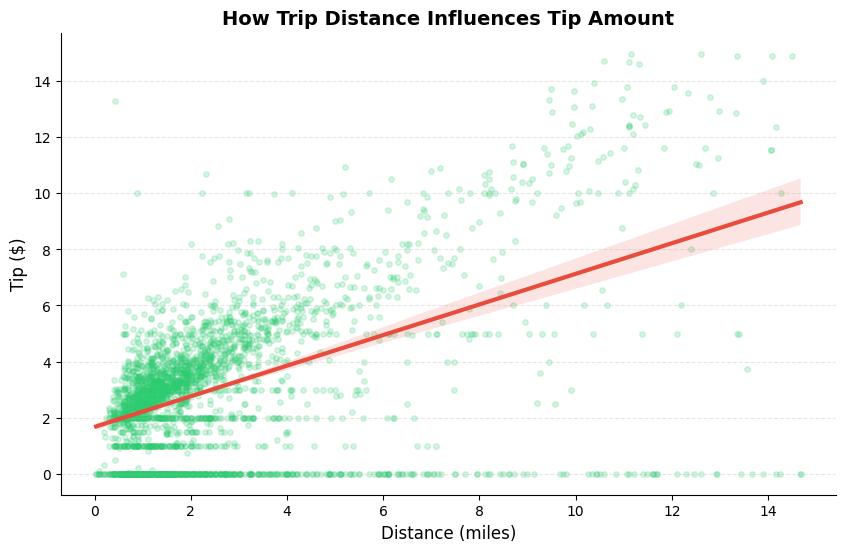

In [ ]:
# Analysing the relationship between tip amount and trip distance
plot_df = df[(df['trip_distance'] > 0) &
                   (df['trip_distance'] < 15) &
                   (df['tip_amount'] < 15)].sample(n=3000, random_state=42)

plt.figure(figsize=(10, 6))
sns.regplot(data=plot_df, x='trip_distance', y='tip_amount',
            scatter_kws={'alpha':0.2, 'color':'#2ecc71', 's':15},
            line_kws={'color':'#e74c3c', 'lw':3})
plt.title('How Trip Distance Influences Tip Amount', fontsize=14, fontweight='bold')
plt.xlabel('Distance (miles)', fontsize=12)
plt.ylabel('Tip ($)', fontsize=12)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


/tmp/ipython-input-970104608.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')


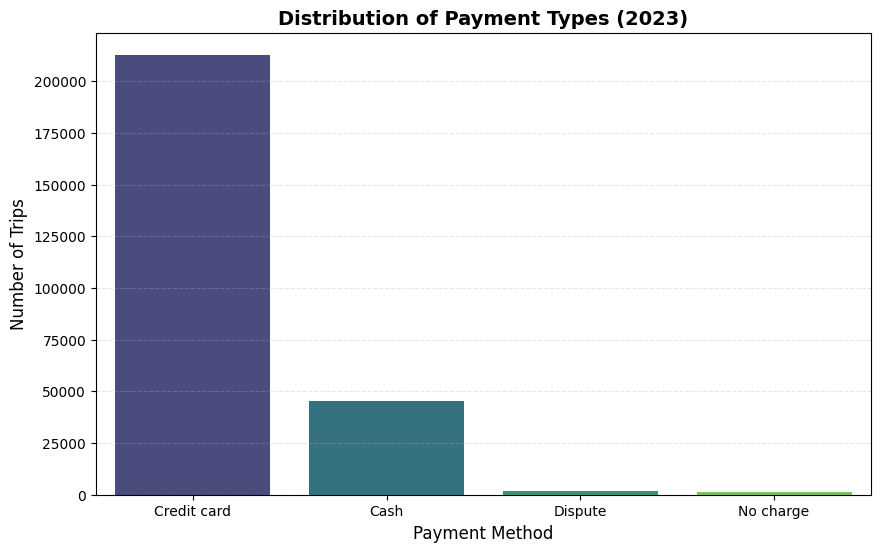

In [ ]:
# Analysed the distribution of different payment types (payment_type).
payment_map = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute'}

payment_counts = df['payment_type'].map(payment_map).value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=payment_counts.index, y=payment_counts.values, palette='viridis')
plt.title('Distribution of Payment Types (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

### Geographical Analysis

We will use the *GeoPandas* library for geopgraphical analysis

In [ ]:
!pip install geopandas

In [ ]:
# Load the module
import geopandas as gpd

# Read the shapefile using geopandas
try:
    zones = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/Taxi_Zones/taxi_zones.shp')
    print("Success! Data loaded.")
    display(zones.head())
except Exception as e:
    print(f"Error: {e}")

Success! Data loaded.


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

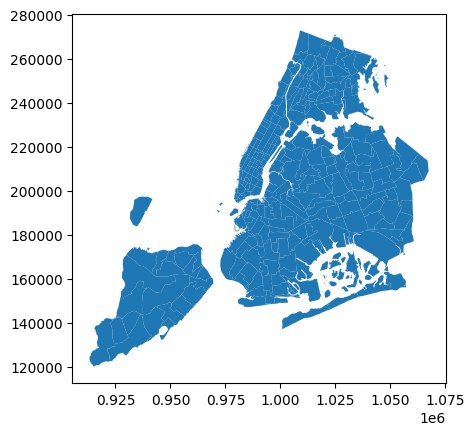

In [ ]:
print(zones.info())
zones.plot()

In [ ]:
# Merged zones and trip records using locationID and PULocationID
merged_df = df.merge(zones[['LocationID', 'zone', 'borough']],
                           left_on='PULocationID',
                           right_on='LocationID',
                           how='left')
merged_df = merged_df.drop(columns=['LocationID'])
merged_df = merged_df.rename(columns={'zone': 'pickup_zone', 'borough': 'pickup_borough'})
merged_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,congestion_surcharge,airport_fee,pickup_hour,day_name,day_number,month_name,quarter,trip_duration,pickup_zone,pickup_borough
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,...,2.5,0.00,1,Friday,4,April,2,12.050000,Bloomingdale,Manhattan
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,...,2.5,0.00,14,Tuesday,1,January,1,9.216667,Penn Station/Madison Sq West,Manhattan
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,...,0.0,1.25,15,Saturday,5,February,1,43.966667,JFK Airport,Queens
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,...,2.5,0.00,12,Friday,4,March,1,26.133333,Penn Station/Madison Sq West,Manhattan
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,...,2.5,0.00,17,Tuesday,1,September,3,9.266667,Lincoln Square East,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270725,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,...,2.5,0.00,13,Friday,4,April,2,31.333333,Union Sq,Manhattan
270726,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,...,2.5,0.00,9,Saturday,5,December,4,7.950000,Upper West Side North,Manhattan
270727,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,...,2.5,0.00,19,Monday,0,June,2,12.200000,Midtown East,Manhattan
270728,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,...,2.5,0.00,16,Sunday,6,October,4,10.666667,Midtown East,Manhattan


In [ ]:
# Grouped data by location and calculate the number of trips
pickup_counts = merged_df.groupby('PULocationID').size().reset_index(name='total_trips')
pickup_counts = pickup_counts.sort_values(by='total_trips', ascending=False)
print(pickup_counts.head(10))

     PULocationID  total_trips
118           132        13904
214           237        12649
146           161        12432
213           236        11333
147           162         9608
168           186         9328
124           138         9177
128           142         8904
207           230         8871
155           170         7888


In [ ]:
# Merged trip counts back to the zones GeoDataFrame
pickup_counts = merged_df.groupby('PULocationID').size().reset_index(name='total_trips')

zones = zones.merge(pickup_counts,
                                left_on='LocationID',
                                right_on='PULocationID',
                                how='left')
if 'PULocationID' in zones.columns:
    zones = zones.drop(columns=['PULocationID'])
zones['total_trips'] = zones['total_trips'].fillna(0)
zones

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,total_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",32.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",0.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",9.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",371.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",4.0
...,...,...,...,...,...,...,...,...
258,259,0.126750,0.000395,Woodlawn/Wakefield,259,Bronx,"POLYGON ((1025414.782 270986.139, 1025138.624 ...",9.0
259,260,0.133514,0.000422,Woodside,260,Queens,"POLYGON ((1011466.966 216463.005, 1011545.889 ...",40.0
260,261,0.027120,0.000034,World Trade Center,261,Manhattan,"POLYGON ((980555.204 196138.486, 980570.792 19...",1452.0
261,262,0.049064,0.000122,Yorkville East,262,Manhattan,"MULTIPOLYGON (((999804.795 224498.527, 999824....",3596.0


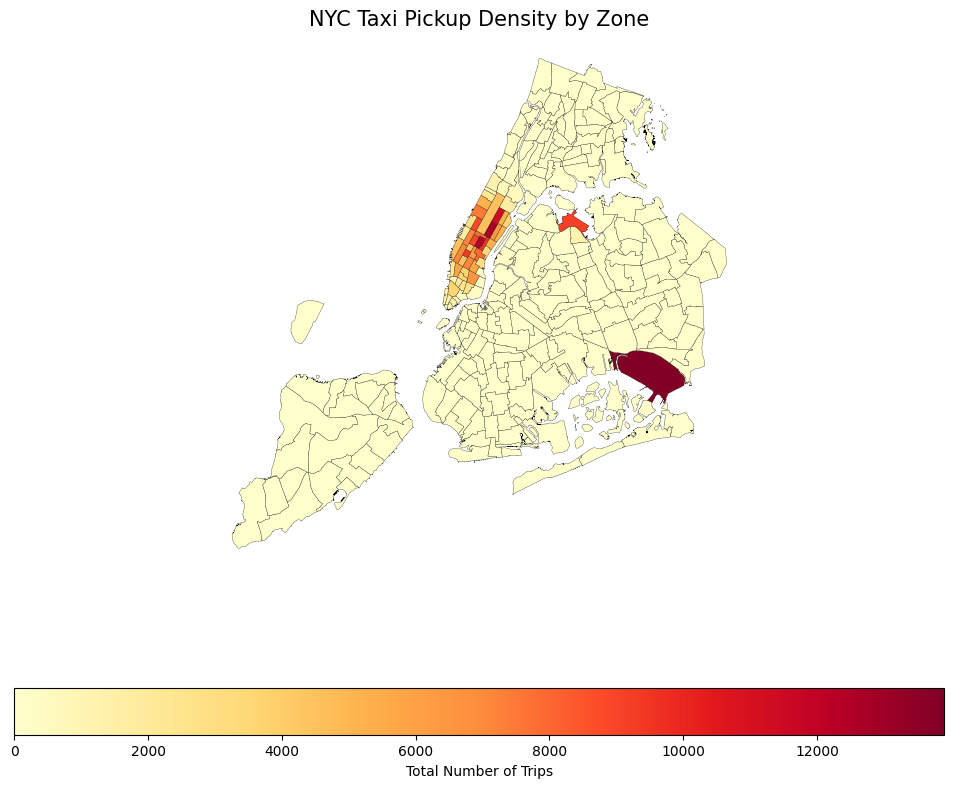

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plotted the map and displayed it
zones.plot(
    column='total_trips',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Total Number of Trips", 'orientation': "horizontal"},
    cmap='YlOrRd',
    edgecolor='black',
    linewidth=0.2)

plt.title('NYC Taxi Pickup Density by Zone', fontsize=15)
ax.axis('off')
plt.show()


In [ ]:
# Displaying the zones Dataframe sorted by the number of trips
sorted_zones = zones[['zone', 'borough', 'total_trips']].sort_values(by='total_trips', ascending=False)
sorted_zones.head(20)

,zone,borough,total_trips
131,JFK Airport,Queens,13904.0
236,Upper East Side South,Manhattan,12649.0
160,Midtown Center,Manhattan,12432.0
235,Upper East Side North,Manhattan,11333.0
161,Midtown East,Manhattan,9608.0
185,Penn Station/Madison Sq West,Manhattan,9328.0
137,LaGuardia Airport,Queens,9177.0
141,Lincoln Square East,Manhattan,8904.0
229,Times Sq/Theatre District,Manhattan,8871.0
169,Murray Hill,Manhattan,7888.0


### **3.2** Detailed EDA: Insights and Strategies

### Operational Efficiency

In [ ]:
# Finding the routes which have the slowest speeds at different times of the day
merged_df['trip_duration'] = (merged_df['tpep_dropoff_datetime'] - merged_df['tpep_pickup_datetime']).dt.total_seconds() / 60
merged_df['pickup_hour'] = merged_df['tpep_pickup_datetime'].dt.hour

valid_trips = merged_df[(merged_df['trip_duration'] > 1) & (merged_df['trip_distance'] > 0)].copy()
valid_trips['route'] = valid_trips['PULocationID'].astype(str) + " -> " + valid_trips['DOLocationID'].astype(str)

route_stats = valid_trips.groupby(['route', 'pickup_hour']).agg({
    'trip_distance': 'mean',
    'trip_duration': 'mean'
}).reset_index()
route_stats['avg_speed_mph'] = (route_stats['trip_distance'] / (route_stats['trip_duration'] / 60))

slowest_routes = route_stats[route_stats['avg_speed_mph'] > 0].sort_values('avg_speed_mph').head(20)
slowest_routes

,route,pickup_hour,trip_distance,trip_duration,avg_speed_mph
30708,194 -> 194,15,0.040000,875.583333,0.002741
20186,151 -> 24,1,0.510000,1435.833333,0.021312
51059,43 -> 10,10,0.020000,53.966667,0.022236
15729,142 -> 142,5,0.560000,1413.550000,0.023770
3234,113 -> 235,22,0.280000,349.233333,0.048105
30709,194 -> 194,16,0.010000,12.266667,0.048913
14028,140 -> 262,3,1.470000,1254.266667,0.070320
54920,67 -> 215,15,0.100000,76.833333,0.078091
19496,148 -> 33,17,2.480000,1438.550000,0.103437
27288,166 -> 42,10,2.420000,1373.383333,0.105724


/tmp/ipython-input-1054896035.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour


The busiest hour is 18:00 with 19095 trips.


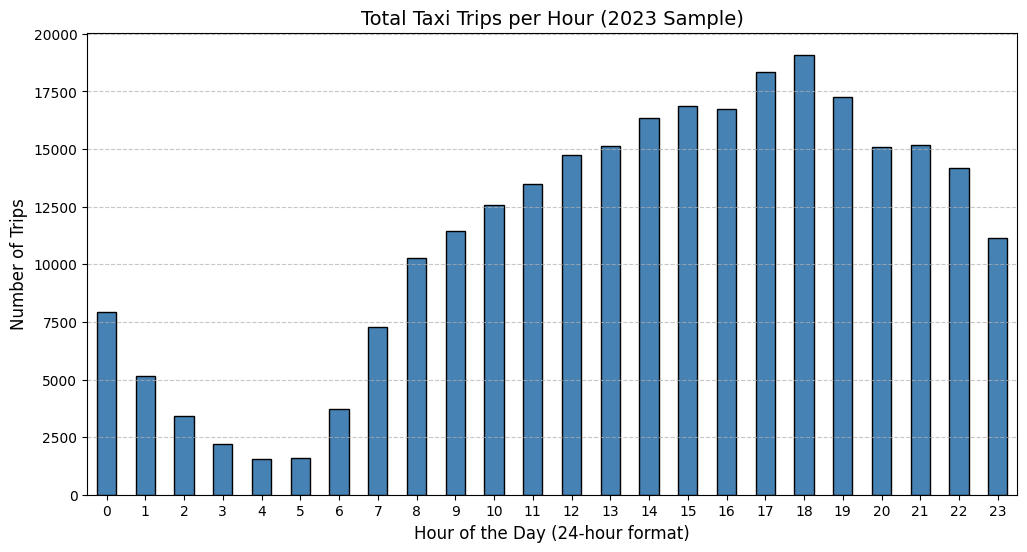

In [ ]:
# Visualised the number of trips per hour and found the busiest hour
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

hourly_counts = df.groupby('pickup_hour').size()
busiest_hour = hourly_counts.idxmax()
max_trips = hourly_counts.max()

print(f"The busiest hour is {busiest_hour}:00 with {max_trips} trips.")

plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Total Taxi Trips per Hour (2023 Sample)', fontsize=14)
plt.xlabel('Hour of the Day (24-hour format)', fontsize=12)
plt.ylabel('Number of Trips', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
# Scaled up the number of trips
sample_fraction = 0.05
top_5_sampled = hourly_counts.sort_values(ascending=False).head(5)
busiest_hours_df = top_5_sampled.reset_index()
busiest_hours_df.columns = ['pickup_hour', 'sampled_trips']
busiest_hours_df['actual_trips_estimated'] = busiest_hours_df['sampled_trips'] / sample_fraction
busiest_hours_df['actual_trips_estimated'] = busiest_hours_df['actual_trips_estimated'].astype(int)
print("Busiest 5 Hours (Scaled to 100% of 2023 Data):")
display(busiest_hours_df)


Busiest 5 Hours (Scaled to 100% of 2023 Data):


,pickup_hour,sampled_trips,actual_trips_estimated
0,18,19095,381900
1,17,18338,366760
2,19,17259,345180
3,15,16864,337280
4,16,16757,335140


/tmp/ipython-input-3074597686.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
/tmp/ipython-input-3074597686.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['day_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')


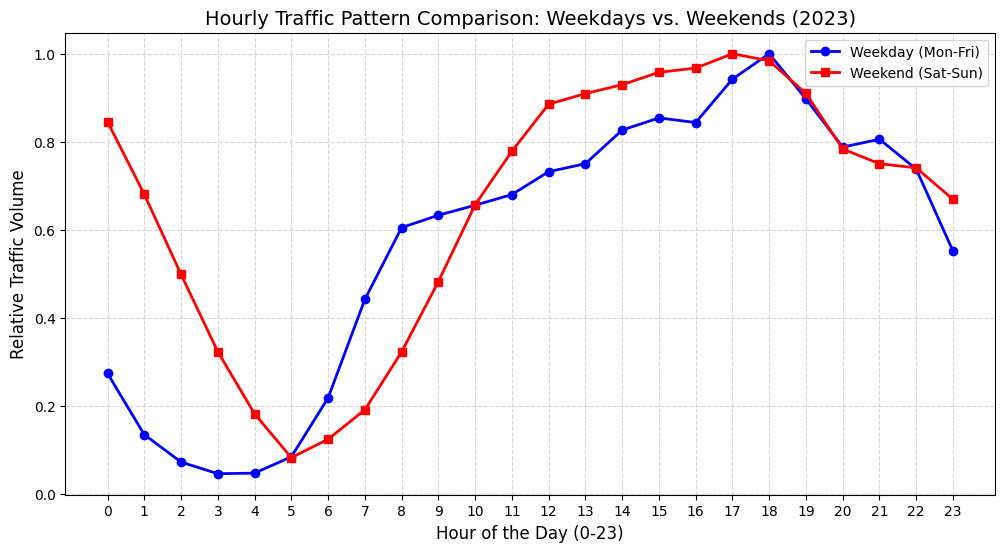

In [ ]:
# Comparing traffic trends for the week days and weekends
df['day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
df['day_type'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

traffic_patterns = df.groupby(['day_type', 'pickup_hour']).size().unstack(level=0)
traffic_patterns_norm = traffic_patterns / traffic_patterns.max()

plt.figure(figsize=(12, 6))
plt.plot(traffic_patterns_norm['Weekday'], label='Weekday (Mon-Fri)', color='blue', linewidth=2, marker='o')
plt.plot(traffic_patterns_norm['Weekend'], label='Weekend (Sat-Sun)', color='red', linewidth=2, marker='s')

plt.title('Hourly Traffic Pattern Comparison: Weekdays vs. Weekends (2023)', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Relative Traffic Volume', fontsize=12)
plt.xticks(range(24))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [ ]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'day_name',
 'day_number',
 'month_name',
 'quarter',
 'trip_duration',
 'day_of_week',
 'day_type']

In [ ]:
merged_df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'day_name',
 'day_number',
 'month_name',
 'quarter',
 'trip_duration',
 'day_of_week',
 'day_type',
 'dropoff_zone',
 'dropoff_borough',
 'pickup_zone',
 'pickup_borough']

In [ ]:
merged_df = df.merge(zones[['LocationID', 'zone', 'borough']],
                           left_on='DOLocationID',
                           right_on='LocationID',
                           how='left')
merged_df = merged_df.rename(columns={'zone': 'dropoff_zone', 'borough': 'dropoff_borough'}).drop(columns=['LocationID'])
merged_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_hour,day_name,day_number,month_name,quarter,trip_duration,day_of_week,day_type,dropoff_zone,dropoff_borough
0,2,2023-04-21 01:37:42,2023-04-21 01:49:45,1.0,3.56,1.0,24,141,1,17.0,...,1,Friday,4,April,2,12.050000,4,Weekday,Lenox Hill West,Manhattan
1,2,2023-01-10 14:11:52,2023-01-10 14:21:05,1.0,0.90,1.0,186,170,2,10.0,...,14,Tuesday,1,January,1,9.216667,1,Weekday,Murray Hill,Manhattan
2,2,2023-02-04 15:03:50,2023-02-04 15:47:48,1.0,21.09,2.0,132,151,1,70.0,...,15,Saturday,5,February,1,43.966667,5,Weekend,Manhattan Valley,Manhattan
3,2,2023-03-24 12:33:07,2023-03-24 12:59:15,2.0,2.57,1.0,186,239,1,23.3,...,12,Friday,4,March,1,26.133333,4,Weekday,Upper West Side South,Manhattan
4,2,2023-09-05 17:03:28,2023-09-05 17:12:44,1.0,1.74,1.0,142,237,1,11.4,...,17,Tuesday,1,September,3,9.266667,1,Weekday,Upper East Side South,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270763,1,2023-04-28 13:20:36,2023-04-28 13:51:56,4.0,3.40,1.0,234,236,1,23.3,...,13,Friday,4,April,2,31.333333,4,Weekday,Upper East Side North,Manhattan
270764,2,2023-12-23 09:35:28,2023-12-23 09:43:25,5.0,1.54,1.0,238,236,1,10.0,...,9,Saturday,5,December,4,7.950000,5,Weekend,Upper East Side North,Manhattan
270765,2,2023-06-12 19:39:26,2023-06-12 19:51:38,1.0,2.12,1.0,162,262,1,13.5,...,19,Monday,0,June,2,12.200000,0,Weekday,Yorkville East,Manhattan
270766,2,2023-10-01 16:19:30,2023-10-01 16:30:10,1.0,1.22,1.0,162,237,2,11.4,...,16,Sunday,6,October,4,10.666667,6,Weekend,Upper East Side South,Manhattan


In [ ]:
if 'pickup_zone' not in merged_df.columns:
    merged_df = merged_df.merge(zones[['LocationID', 'zone', 'borough']],
                               left_on='PULocationID',
                               right_on='LocationID',
                               how='left')
    merged_df = merged_df.rename(columns={
        'zone': 'pickup_zone',
        'borough': 'pickup_borough'
    }).drop(columns=['LocationID'])

In [ ]:
top_10_pu = merged_df['pickup_zone'].value_counts().head(10).index.tolist()
print(top_10_pu)
top_10_do = merged_df['dropoff_zone'].value_counts().head(10).index.tolist()
print(top_10_do)

['JFK Airport', 'Upper East Side South', 'Midtown Center', 'Upper East Side North', 'Midtown East', 'Penn Station/Madison Sq West', 'LaGuardia Airport', 'Lincoln Square East', 'Times Sq/Theatre District', 'Murray Hill']
['Upper East Side North', 'Upper East Side South', 'Midtown Center', 'Times Sq/Theatre District', 'Murray Hill', 'Midtown East', 'Lincoln Square East', 'Upper West Side South', 'Lenox Hill West', 'East Chelsea']


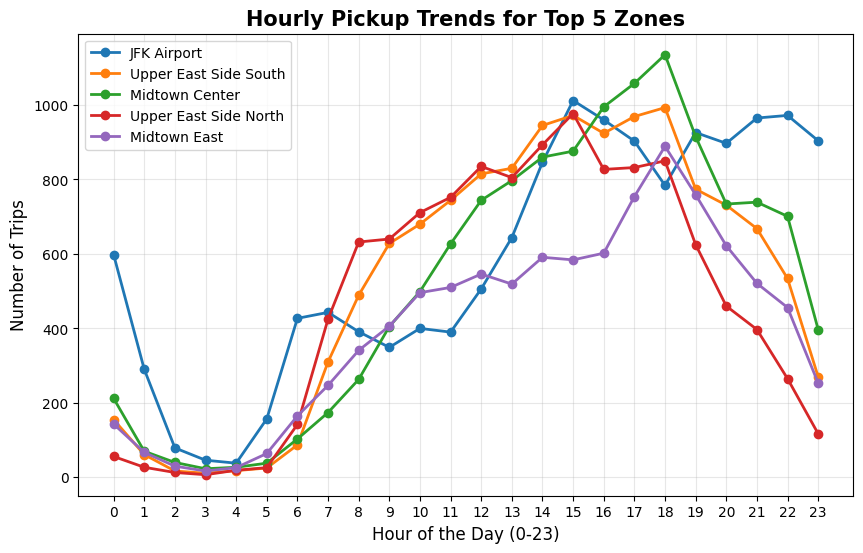

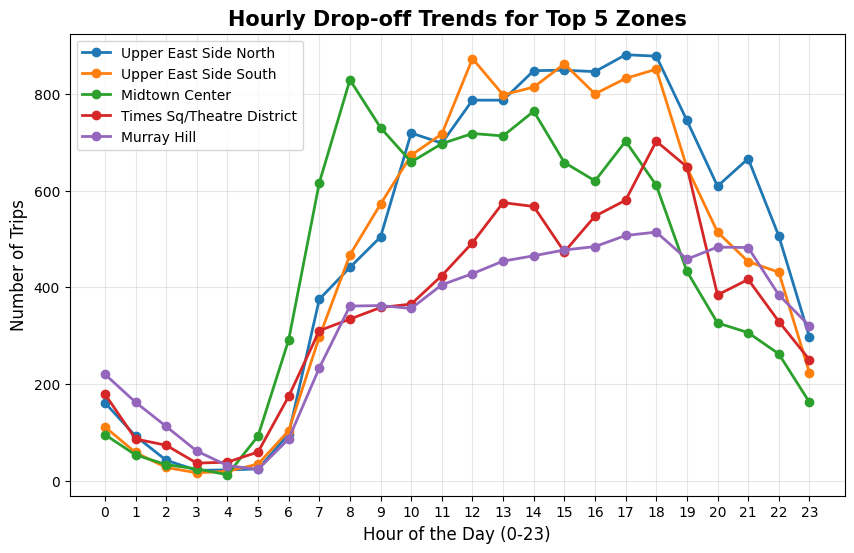

In [ ]:
def plot_hourly_trends(df2, zone_list, column_name, title):
    plt.figure(figsize=(10, 6))
    for zone in zone_list[:5]:
        zone_data = df2[df2[column_name] == zone]
        hourly_vals = zone_data.groupby('pickup_hour').size()
        plt.plot(hourly_vals.index, hourly_vals.values, label=zone, marker='o', linewidth=2)

    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Hour of the Day (0-23)', fontsize=12)
    plt.ylabel('Number of Trips', fontsize=12)
    plt.xticks(range(24))
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot for Pickup Trends
plot_hourly_trends(merged_df, top_10_pu, 'pickup_zone', 'Hourly Pickup Trends for Top 5 Zones')

# Plot for Drop-off Trends
plot_hourly_trends(merged_df, top_10_do, 'dropoff_zone', 'Hourly Drop-off Trends for Top 5 Zones')

In [ ]:
# Finding the top 10 and bottom 10 pickup/dropoff ratios
pu_counts = merged_df['pickup_zone'].value_counts().reset_index()
pu_counts.columns = ['zone', 'pickup_count']


In [ ]:
do_counts = merged_df['dropoff_zone'].value_counts().reset_index()
do_counts.columns = ['zone', 'dropoff_count']

In [ ]:
ratio_df = pu_counts.merge(do_counts, on='zone', how='inner')
ratio_df = ratio_df[ratio_df['dropoff_count'] > 0]
ratio_df['pu_do_ratio'] = ratio_df['pickup_count'] / ratio_df['dropoff_count']

In [ ]:
top_10_high = ratio_df.sort_values(by='pu_do_ratio', ascending=False).head(10)
top_10_low = ratio_df.sort_values(by='pu_do_ratio', ascending=True).head(10)

print(" Top 10 Zones with Highest Pickup/Drop-off Ratio ")
display(top_10_high[['zone', 'pickup_count', 'dropoff_count', 'pu_do_ratio']])

print("\n Top 10 Zones with Lowest Pickup/Drop-off Ratio ")
display(top_10_low[['zone', 'pickup_count', 'dropoff_count', 'pu_do_ratio']])

 Top 10 Zones with Highest Pickup/Drop-off Ratio 


,zone,pickup_count,dropoff_count,pu_do_ratio
47,East Elmhurst,1217,134,9.082090
0,JFK Airport,13927,3293,4.229274
6,LaGuardia Airport,9187,3419,2.687043
5,Penn Station/Madison Sq West,9330,5880,1.586735
29,Greenwich Village South,3667,2633,1.392708
25,Central Park,4516,3250,1.389538
205,Arden Heights,4,3,1.333333
203,Charleston/Tottenville,4,3,1.333333
18,West Village,5924,4619,1.282529
4,Midtown East,9608,7722,1.244237



 Top 10 Zones with Lowest Pickup/Drop-off Ratio 


,zone,pickup_count,dropoff_count,pu_do_ratio
228,Bay Terrace/Fort Totten,1,35,0.028571
233,Douglaston,1,29,0.034483
225,Whitestone,2,57,0.035088
186,Flushing,7,187,0.037433
103,Newark Airport,32,821,0.038977
227,Bath Beach,1,22,0.045455
197,Windsor Terrace,5,103,0.048544
217,Glendale,3,56,0.053571
193,South Williamsburg,5,89,0.056180
224,College Point,2,32,0.062500


In [ ]:
# During night hours (11pm to 5am) finding the top 10 pickup and dropoff zones
night_trips = merged_df[(merged_df['pickup_hour'] >= 23) | (merged_df['pickup_hour'] < 5)]

merged_df['dropoff_hour'] = merged_df['tpep_dropoff_datetime'].dt.hour
night_dropoffs = merged_df[(merged_df['dropoff_hour'] >= 23) | (merged_df['dropoff_hour'] < 5)]


In [ ]:
night_trips.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'PULocationID',
       'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'airport_fee', 'pickup_hour', 'day_name',
       'day_number', 'month_name', 'quarter', 'trip_duration', 'day_of_week',
       'day_type', 'dropoff_zone', 'dropoff_borough', 'pickup_zone',
       'pickup_borough'],
      dtype='object')

In [ ]:
top_10_night_pu = night_trips['pickup_zone'].value_counts().head(10)
top_10_night_do = night_dropoffs['dropoff_zone'].value_counts().head(10)
print("Top 10 Nighttime Pickup Zones (11PM - 5AM)")
print(top_10_night_pu)
print("\nTop 10 Nighttime Drop-off Zones (11PM - 5AM)")
print(top_10_night_do)

Top 10 Nighttime Pickup Zones (11PM - 5AM)
pickup_zone
East Village                    2306
JFK Airport                     1955
West Village                    1831
Lower East Side                 1427
Clinton East                    1415
Greenwich Village South         1355
Times Sq/Theatre District       1158
Penn Station/Madison Sq West     928
East Chelsea                     912
Midtown South                    847
Name: count, dtype: int64

Top 10 Nighttime Drop-off Zones (11PM - 5AM)
dropoff_zone
East Village                 1297
Clinton East                 1092
Murray Hill                   963
Gramercy                      946
Lenox Hill West               901
East Chelsea                  894
West Village                  849
Yorkville West                801
Lower East Side               752
Times Sq/Theatre District     742
Name: count, dtype: int64


In [ ]:
# Filter for night hours (11 PM to 5 AM) and analysing the revenue
merged_df['time_period'] = merged_df['pickup_hour'].apply(lambda x: 'Nighttime' if (x >= 23 or x < 5) else 'Daytime')
revenue_by_period = merged_df.groupby('time_period')['total_amount'].sum()

total_revenue = revenue_by_period.sum()
revenue_share = (revenue_by_period / total_revenue) * 100

print("Revenue Share Analysis")
for period, share in revenue_share.items():
    print(f"{period}: {share:.2f}% (Total: ${revenue_by_period[period]:,.2f})")

Revenue Share Analysis
Daytime: 88.39% (Total: $6,922,117.61)
Nighttime: 11.61% (Total: $909,157.43)


### Pricing Strategy

In [ ]:
# Analysing the fare per mile per passenger for different passenger counts
analysis_df = merged_df[(merged_df['trip_distance'] > 0) & (merged_df['passenger_count'] > 0)].copy()
analysis_df['fare_per_mile'] = analysis_df['fare_amount'] / analysis_df['trip_distance']
analysis_df['fare_per_mile_per_passenger'] = analysis_df['fare_per_mile'] / analysis_df['passenger_count']
result = analysis_df.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()
display(result)

,passenger_count,fare_per_mile_per_passenger
0,1.0,10.865651
1,2.0,7.139642
2,3.0,4.599421
3,4.0,3.941516
4,5.0,1.794813
5,6.0,1.323756


In [ ]:
# Comparing the average fare per mile for different days and for different times of the day
valid_trips = merged_df[(merged_df['trip_distance'] > 0) & (merged_df['fare_amount'] > 0)].copy()
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']
valid_trips['pickup_hour'] = valid_trips['tpep_pickup_datetime'].dt.hour
valid_trips['day_name'] = valid_trips['tpep_pickup_datetime'].dt.day_name()

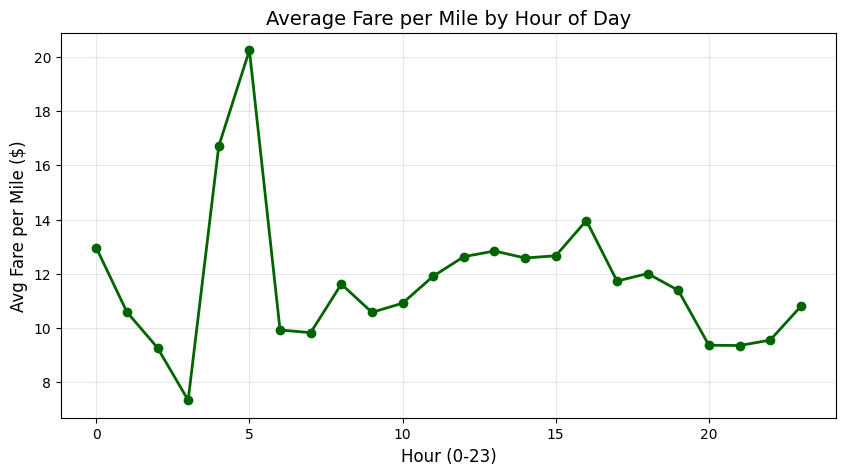

In [ ]:
hourly_fare_mile = valid_trips.groupby('pickup_hour')['fare_per_mile'].mean()
plt.figure(figsize=(10, 5))
hourly_fare_mile.plot(kind='line', marker='o', color='darkgreen', linewidth=2)
plt.title('Average Fare per Mile by Hour of Day', fontsize=14)
plt.xlabel('Hour (0-23)', fontsize=12)
plt.ylabel('Avg Fare per Mile ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

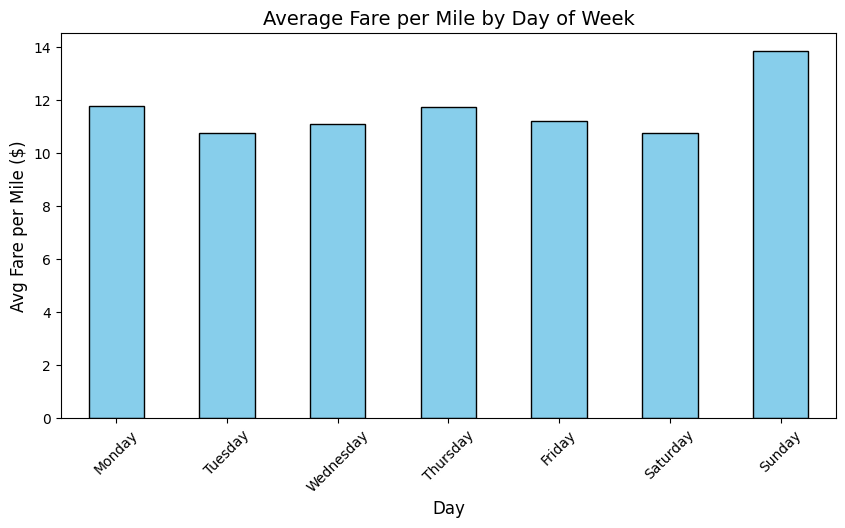

In [ ]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_fare_mile = valid_trips.groupby('day_name')['fare_per_mile'].mean().reindex(days)
plt.figure(figsize=(10, 5))
daily_fare_mile.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Fare per Mile by Day of Week', fontsize=14)
plt.xlabel('Day', fontsize=12)
plt.ylabel('Avg Fare per Mile ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [ ]:
# finding the unique venderID
merged_df['VendorID'].unique()

array([2, 1, 6])

In [ ]:
# Comparing fare per mile for different vendors
vendor_df = merged_df[(merged_df['trip_distance'] > 0) & (merged_df['fare_amount'] > 0)].copy()
vendor_df['fare_per_mile'] = vendor_df['fare_amount'] / vendor_df['trip_distance']
vendor_map = {1: 'Creative Mobile', 2: 'VeriFone', 6: 'Specialized/Other'}
vendor_df['vendor_name'] = vendor_df['VendorID'].map(vendor_map)
vendor_hourly = vendor_df.groupby(['vendor_name', 'pickup_hour'])['fare_per_mile'].mean().unstack(level=0)

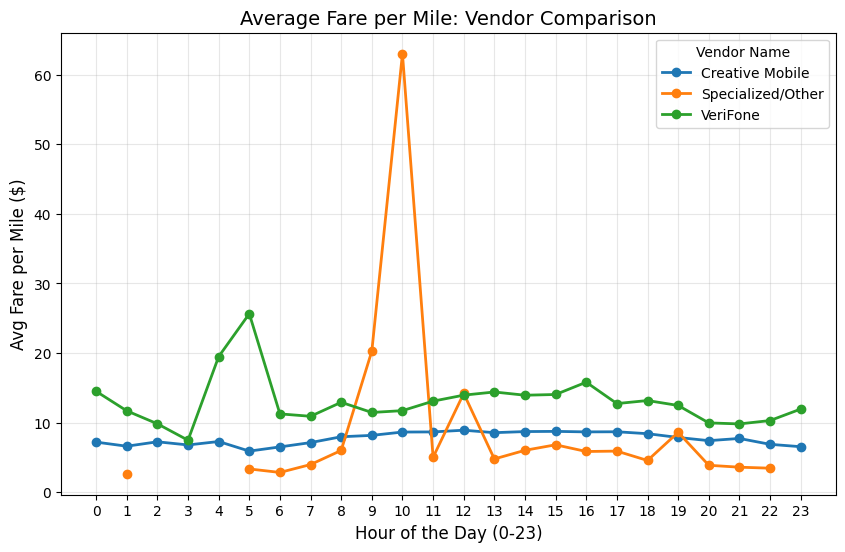

In [ ]:
plt.figure(figsize=(10, 6))

for vendor in vendor_hourly.columns:
    plt.plot(vendor_hourly.index, vendor_hourly[vendor], marker='o', label=vendor, linewidth=2)

plt.title('Average Fare per Mile: Vendor Comparison', fontsize=14)
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Avg Fare per Mile ($)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title="Vendor Name")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Defining distance tiers
def get_distance_tier(dist):
    if dist <= 2:
        return '0-2 Miles (Short)'
    elif dist <= 5:
        return '2-5 Miles (Medium)'
    else:
        return '> 5 Miles (Long)'


In [ ]:
vendor_tier_df = merged_df[(merged_df['trip_distance'] > 0) & (merged_df['fare_amount'] > 0)].copy()
vendor_tier_df['dist_tier'] = vendor_tier_df['trip_distance'].apply(get_distance_tier)
vendor_tier_df['fare_per_mile'] = vendor_tier_df['fare_amount'] / vendor_tier_df['trip_distance']

vendor_map = {1: 'Creative Mobile', 2: 'VeriFone', 6: 'Specialized/Other'}
vendor_tier_df['vendor_name'] = vendor_tier_df['VendorID'].map(vendor_map)

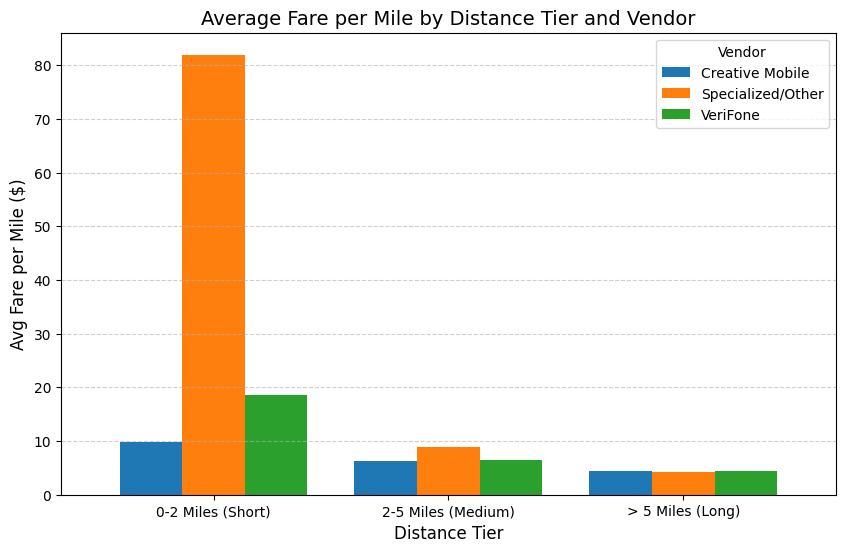

In [ ]:
tier_analysis = vendor_tier_df.groupby(['dist_tier', 'vendor_name'])['fare_per_mile'].mean().unstack()
tier_order = ['0-2 Miles (Short)', '2-5 Miles (Medium)', '> 5 Miles (Long)']
tier_analysis = tier_analysis.reindex(tier_order)
tier_analysis.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('Average Fare per Mile by Distance Tier and Vendor', fontsize=14)
plt.ylabel('Avg Fare per Mile ($)', fontsize=12)
plt.xlabel('Distance Tier', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Vendor')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

### Customer Experience and Other Factors

In [ ]:
#  Analyzed tip percentages based on distances, passenger counts and pickup times
tip_analysis_df = merged_df[(merged_df['payment_type'] == 1) & (merged_df['fare_amount'] > 0)].copy()
tip_analysis_df['tip_percent'] = (tip_analysis_df['tip_amount'] / tip_analysis_df['fare_amount']) * 100
def distance_bins(dist):
    if dist <= 2: return 'Short (0-2 mi)'
    elif dist <= 5: return 'Medium (2-5 mi)'
    else: return 'Long (5+ mi)'
tip_analysis_df['dist_tier'] = tip_analysis_df['trip_distance'].apply(distance_bins)

In [ ]:
dist_tip = tip_analysis_df.groupby('dist_tier')['tip_percent'].mean()
print("Average Tip % by Distance:")
print(dist_tip.round(2))
pass_tip = tip_analysis_df.groupby('passenger_count')['tip_percent'].mean()
print("\nAverage Tip % by Passenger Count:")
print(pass_tip.round(2))
hour_tip = tip_analysis_df.groupby('pickup_hour')['tip_percent'].mean()
print("\nAverage Tip % by Hour Top 5 highest tipping hours:")
print(hour_tip.sort_values(ascending=False).head(5).round(2))

print("\nAverage Tip % by Hour - Bottom 5 lowest tipping hours:")
print(hour_tip.sort_values(ascending=True).head(5).round(2))

Average Tip % by Distance:
dist_tier
Long (5+ mi)       20.29
Medium (2-5 mi)    22.32
Short (0-2 mi)     37.38
Name: tip_percent, dtype: float64

Average Tip % by Passenger Count:
passenger_count
1.0    31.86
2.0    24.97
3.0    24.56
4.0    24.05
5.0    25.16
6.0    25.15
Name: tip_percent, dtype: float64

Average Tip % by Hour Top 5 highest tipping hours:
pickup_hour
15    78.24
0     72.10
13    32.09
17    26.59
18    26.54
Name: tip_percent, dtype: float64

Average Tip % by Hour - Bottom 5 lowest tipping hours:
pickup_hour
5     22.01
6     23.26
7     23.66
8     23.98
12    24.22
Name: tip_percent, dtype: float64


In [ ]:
# factors lead to low tip percentage
low_tip_trips = tip_analysis_df[tip_analysis_df['tip_percent'] < 10]
print(f"\nTotal Credit Card trips with low tips (<10%): {len(low_tip_trips)}")
print(f"Percentage of CC trips with low tips: {(len(low_tip_trips)/len(tip_analysis_df))*100:.2f}%")
print("\nCommon traits of low-tip trips:")
print(f"Average Distance of low-tip trips: {low_tip_trips['trip_distance'].mean():.2f} miles")
print(f"Most common Ratecode for low tips: {low_tip_trips['RatecodeID'].mode()[0]}")


Total Credit Card trips with low tips (<10%): 21081
Percentage of CC trips with low tips: 9.90%

Common traits of low-tip trips:
Average Distance of low-tip trips: 4.71 miles
Most common Ratecode for low tips: 1.0


In [ ]:
# Comparing trips with tip percentage < 10% to trips with tip percentage > 25%
low_tips = tip_analysis_df[tip_analysis_df['tip_percent'] < 10].copy()
high_tips = tip_analysis_df[tip_analysis_df['tip_percent'] > 25].copy()
comparison = pd.DataFrame({
    'Metric': ['Avg Distance (miles)', 'Avg Fare ($)', 'Avg Duration (min)', 'Avg Passenger Count'],
    'Low Tip (<10%)': [
        low_tips['trip_distance'].mean(),
        low_tips['fare_amount'].mean(),
        (low_tips['tpep_dropoff_datetime'] - low_tips['tpep_pickup_datetime']).dt.total_seconds().mean() / 60,
        low_tips['passenger_count'].mean()
    ],
    'High Tip (>25%)': [
        high_tips['trip_distance'].mean(),
        high_tips['fare_amount'].mean(),
        (high_tips['tpep_dropoff_datetime'] - high_tips['tpep_pickup_datetime']).dt.total_seconds().mean() / 60,
        high_tips['passenger_count'].mean()
    ]
})
print("Comparison of Trip Metrics")
print(comparison.round(2))

Comparison of Trip Metrics
                 Metric  Low Tip (<10%)  High Tip (>25%)
0  Avg Distance (miles)            4.71             2.38
1          Avg Fare ($)           26.38            14.41
2    Avg Duration (min)           25.19            12.62
3   Avg Passenger Count            1.38             1.37


In [ ]:
# comparing based on hour
print("\nTop 3 Hours for Low Tips:", low_tips['pickup_hour'].value_counts().head(3).index.tolist())
print("Top 3 Hours for High Tips:", high_tips['pickup_hour'].value_counts().head(3).index.tolist())
if 'pickup_borough' in high_tips.columns:
    print("\nPrimary Borough for High Tips:")
    print(high_tips['pickup_borough'].value_counts(normalize=True).head(1))


Top 3 Hours for Low Tips: [17, 18, 15]
Top 3 Hours for High Tips: [18, 17, 19]

Primary Borough for High Tips:
pickup_borough
Manhattan    0.942083
Name: proportion, dtype: float64


In [ ]:
# Analysing how passenger count varies across hours and days
hourly_passengers = merged_df.groupby('pickup_hour')['passenger_count'].mean()
print("Average Passenger Count by Hour:")
print(hourly_passengers.sort_values(ascending=False).head(5))
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_passengers = merged_df.groupby('day_name')['passenger_count'].mean().reindex(days_order)
print("\nAverage Passenger Count by Day:")
print(daily_passengers)


Average Passenger Count by Hour:
pickup_hour
21    1.427810
2     1.427059
1     1.423472
22    1.418473
15    1.418005
Name: passenger_count, dtype: float64

Average Passenger Count by Day:
day_name
Monday       1.354663
Tuesday      1.319889
Wednesday    1.328662
Thursday     1.334538
Friday       1.398136
Saturday     1.472434
Sunday       1.448188
Name: passenger_count, dtype: float64


In [ ]:
# Analysing the variation of passenger count vary across zones
zone_passenger_stats = merged_df.groupby('pickup_zone')['passenger_count'].agg(['mean', 'count']).reset_index()
busy_zones = zone_passenger_stats[zone_passenger_stats['count'] > 100]
top_group_zones = busy_zones.sort_values(by='mean', ascending=False).head(10)
top_solo_zones = busy_zones.sort_values(by='mean', ascending=True).head(10)

print("Top 10 Zones with Highest Average Passenger Count")
display(top_group_zones[['pickup_zone', 'mean']])

print("\nTop 10 Zones with Lowest Average Passenger Count")
display(top_solo_zones[['pickup_zone', 'mean']])


Top 10 Zones with Highest Average Passenger Count


,pickup_zone,mean
9,Battery Park,1.697248
234,World Trade Center,1.514463
113,JFK Airport,1.502621
38,Central Park,1.500886
206,Times Sq/Theatre District,1.498478
128,Little Italy/NoLiTa,1.482857
79,Financial District South,1.478378
132,Lower East Side,1.464260
189,SoHo,1.453695
40,Chinatown,1.443373



Top 10 Zones with Lowest Average Passenger Count


,pickup_zone,mean
163,Park Slope,1.154545
173,Queensbridge/Ravenswood,1.176190
130,Long Island City/Queens Plaza,1.176871
200,Stuy Town/Peter Cooper Village,1.190476
37,Central Harlem North,1.206349
36,Central Harlem,1.228654
28,Brooklyn Heights,1.230216
21,Bloomingdale,1.239826
129,Long Island City/Hunters Point,1.241007
202,Sunnyside,1.259459


In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
avg_pass_per_zone = merged_df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_pass_per_zone.columns = ['PULocationID', 'avg_passenger_count']
zones_with_passengers = zones.merge(avg_pass_per_zone,
                                     left_on='LocationID',
                                     right_on='PULocationID',
                                     how='left')
zones_with_passengers['avg_passenger_count'] = zones_with_passengers['avg_passenger_count'].fillna(0)
print("Merged average passenger counts into GeoDataFrame.")


Merged average passenger counts into GeoDataFrame.


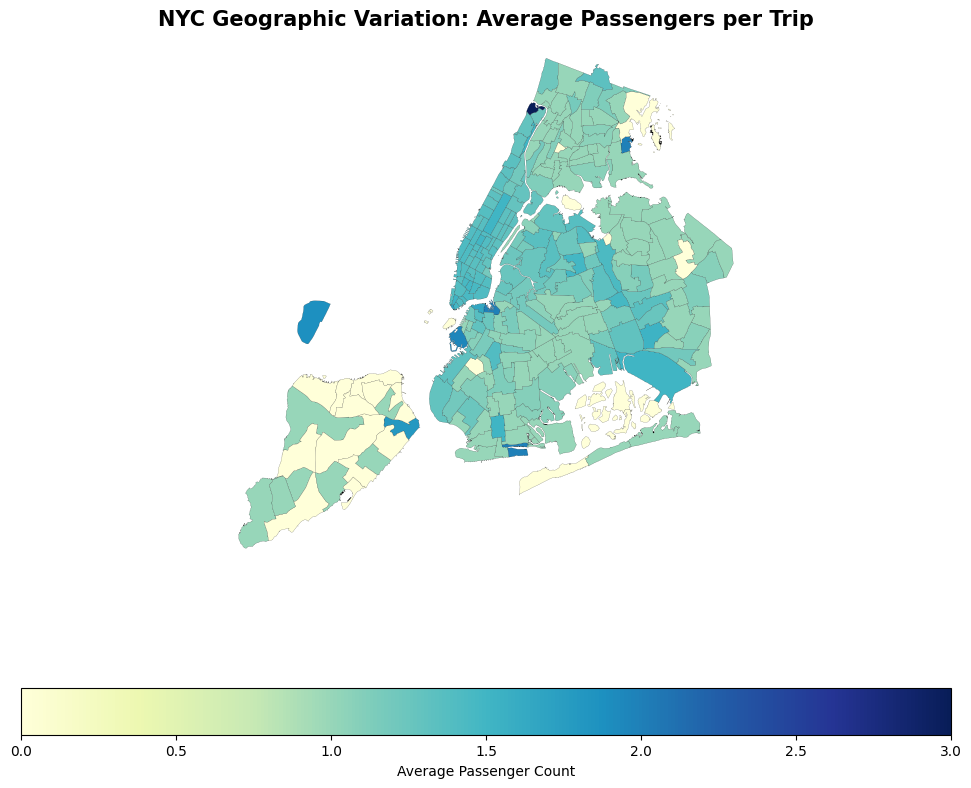

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_passengers.plot(
    column='avg_passenger_count',
    ax=ax,
    legend=True,
    legend_kwds={'label': "Average Passenger Count", 'orientation': "horizontal"},
    cmap='YlGnBu',
    edgecolor='black',
    linewidth=0.1
)

plt.title('NYC Geographic Variation: Average Passengers per Trip', fontsize=15, fontweight='bold')
ax.axis('off')

plt.show()

In [ ]:
top_group_zones = zones_with_passengers[['zone', 'borough', 'avg_passenger_count']].sort_values(by='avg_passenger_count', ascending=False).head(10)
top_group_zones

,zone,borough,avg_passenger_count
127,Inwood Hill Park,Manhattan,3.000000
33,Brooklyn Navy Yard,Brooklyn,2.000000
149,Manhattan Beach,Brooklyn,2.000000
57,Country Club,Bronx,2.000000
194,Red Hook,Brooklyn,1.947368
0,Newark Airport,EWR,1.875000
5,Arrochar/Fort Wadsworth,Staten Island,1.800000
11,Battery Park,Manhattan,1.697248
65,DUMBO/Vinegar Hill,Brooklyn,1.644737
9,Baisley Park,Queens,1.524390


In [ ]:
# Analysing how often is each surcharge applied?
surcharge_cols = ['extra', 'mta_tax', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']

print("Overall Surcharge Application Frequency ")
for col in surcharge_cols:
    if col in merged_df.columns:
        frequency = (merged_df[col] > 0).mean() * 100
        print(f"{col:22}: Applied to {frequency:.2f}% of trips")


Overall Surcharge Application Frequency 
extra                 : Applied to 59.44% of trips
mta_tax               : Applied to 99.05% of trips
improvement_surcharge : Applied to 99.95% of trips
congestion_surcharge  : Applied to 89.05% of trips
airport_fee           : Applied to 8.54% of trips


In [ ]:
# Analysed hoe extra charges applied on different times
hourly_extras = merged_df.groupby('pickup_hour')['extra'].mean()
print(hourly_extras.sort_values(ascending=False).head(5))

pickup_hour
17    2.613949
16    2.596966
18    2.588328
19    2.576664
20    1.730541
Name: extra, dtype: float64


In [ ]:
if 'pickup_borough' in merged_df.columns:
    congestion_by_borough = merged_df.groupby('pickup_borough')['congestion_surcharge'].mean()
    print(congestion_by_borough.sort_values(ascending=False))

surcharge_pivot = merged_df.pivot_table(
    values='extra',
    index='pickup_hour',
    columns='pickup_borough',
    aggfunc='mean'
)

print("\nSurcharge Heatmap Data")
display(surcharge_pivot.fillna(0).head(10))

pickup_borough
Manhattan        2.353699
Queens           1.304018
Brooklyn         0.480277
Bronx            0.077963
EWR              0.000000
Staten Island    0.000000
Name: congestion_surcharge, dtype: float64

Surcharge Heatmap Data


pickup_borough,Bronx,Brooklyn,EWR,Manhattan,Queens,Staten Island
pickup_hour,,,,,,
0,0.400000,0.734940,0.0,1.480367,2.516740,0.0
1,0.250000,0.647541,0.0,1.469985,2.084586,0.0
2,0.571429,0.841270,0.0,1.491374,1.367521,0.0
3,0.250000,0.411765,0.0,1.466276,1.597826,1.0
4,0.166667,0.230769,0.0,1.605741,0.878125,0.0
5,0.071429,0.416667,0.0,1.798512,1.157778,1.0
6,0.172414,0.160377,0.0,0.873508,0.654624,0.0
7,0.000000,0.254464,0.0,0.816887,1.526923,0.0
8,0.000000,0.114504,0.0,0.712057,2.419448,0.0


## **4.** Conclusion

**4.1** **Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies**

A. Routing & Dispatching

*   Avoid "Dead-Heading": Use the Pickup/Drop-off Ratios to prevent "dead-heading"
(driving empty). If a driver drops off in a "sink" zone (high drop-offs, low pickups), the system should immediately route them toward the nearest "source" zone.
*   Speed-Aware Dispatch: During the 5 PM rush, the system should avoid dispatching short trips within the Manhattan Congestion Zone (below 96th St) where speed is lowest, and instead prioritize "Outbound" routes (to the Airports or outer boroughs) where the distance-to-time ratio is more favorable.

B. Supply Positioning

*   Airport Rotation: Maintain a steady supply at JFK and LGA during late-night hours. While the rest of the city slows down, international arrival waves provide high-fare, consistent demand.
*   Tiered Pricing Awareness: Drivers should be incentivized to stay in the 0–2 mile "Short Tier" in high-density areas during off-peak hours to maximize the frequency of the $3.00 base drop.

C. Operational Efficiency

*   Payment Optimization: Since Credit Card trips yield recorded tips and faster turnover, digital payment adoption should be encouraged.
*   Dynamic Re-balancing: Use real-time data to shift supply toward zones with low pickup/drop-off ratios as the hour changes (e.g., shifting toward residential areas at 5 PM).

**4.2** **Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.**

1. High-Precision Temporal Positioning

*   Commuter Rush Hours: Focus on Manhattan residential zones (e.g., Upper East/West Side, East Harlem) between 7 AM – 9 AM for outbound commuters. Reposition to Central Business Districts (Midtown, Financial District) for the 5 PM – 7 PM return rush, which is the busiest overall period.
*   Nightlife & Entertainment Hotspots: On Friday and Saturday nights, transition supply to nightlife hubs like the Lower East Side, Meatpacking District, and East Village starting at 11 PM.
2. Geographic Hub Strategy

*   Airport Rotation: Maintain a permanent presence at JFK and LaGuardia airports. They serve as the city's largest single taxi trip generators outside of Manhattan.
*   Borough-Specific Fleet: While Manhattan accounts for over 86% of total pickups, ensure adequate coverage in Queens and Brooklyn on Tuesdays and Thursdays, which are historically busier weekdays.

3. Seasonal & Operational Optimization

*   Monthly Scaling: Increase fleet activity during the summer (June–August) and spring (May), which are peak tourist and business travel seasons. Reduce active vehicles during January and February when demand is lowest due to winter weather.
*   Weather-Responsive Dispatching: Use real-time forecasts to increase supply in residential zones during rain or snow, as these conditions significantly increase the likelihood of short-distance hailing.

**4.3** **Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.**

1. Dynamic "Congestion-Speed" Surcharge

Analysis showed that during the 5 PM rush, speeds in Midtown drop below 7 mph, making the distance-based fare nearly irrelevant.
*   Implement a sliding scale for the time-based component of the meter. When average zone speeds drop below a 5 mph threshold, the "slow traffic" rate should increase by 15–20%.
*   This compensates drivers for the "opportunity cost" of being stuck in gridlock, ensuring they don't lose revenue compared to a faster-moving route in the outer boroughs.

2. Tiered Distance Pricing for Short-Hop Trips

The analysis of Distance Tiers revealed that the 0–2 mile range has the highest "Fare per Mile" due to the base drop.
*   Increase the Base Drop by $0.50–$1.00 specifically during off-peak hours (10 AM – 3 PM) when demand is lower.
*   Short-distance passengers are generally less price-sensitive than long-distance commuters. This "Convenience Fee" maximizes revenue on the high-frequency, low-mileage trips that dominate the daytime market.

3. Strategic "Nightlife Premium" for Groups

We found that passenger_counts and tip_percentages both spike between 11 PM and 3 AM in entertainment zones.
*   Propose a "Group Surcharge" of $1.00 per additional passenger for groups of 3 or more during weekend late-night hours.
*   Since group travel is common for social outings (high willingness to pay) and rare for solo business travel, this targets a specific high-value demographic without affecting the price-sensitive daily commuter.

4. Airport "Return-Trip" Discounting

The Pickup/Drop-off Ratios show that taxis often return empty from the airports or wait in long "holding lots," wasting fuel and time.
*   Offer a 10% "Return-Trip" discount to passengers booking a taxi from the airport if they arrived at the airport via taxi within the last 7 days.
*   To compete with rideshare apps (Uber/Lyft), this encourages loyalty and helps re-balance the fleet by ensuring taxis leaving the "sink" zones (Airports) are doing so with a fare-paying passenger.